In [ ]:
#Importar las librerias
from pathlib import Path
import sys

# Carpeta raíz del proyecto
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import os
import pandas as pd
import polars as pl
from procesamiento.PolarPreprocessor import PolarsPreprocessor
import tensorflow as tf
import random
import numpy as np
from modelos.LSTMModel import LSTMModel
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from collections import defaultdict
import warnings

warnings.filterwarnings('ignore')


# Fijar la semilla para los modelos neuronales
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
# ================================
# LSTM
# ================================

# 1. Se realiza el preprocesamiento para generar secuencias al dataset (necesario para el algoritmo)
# Se carga el dataset con la libreria de polars



df_polars = pl.read_csv("/data_simulada/dataset_sintetico_completo.csv")
pol_lstm = PolarsPreprocessor(df_polars)
X, y = pol_lstm.run_all(export_path="data_simulada/preprocesado_Polars.csv", generar_secuencias = True)

# 2. Se divide el dataset mediante train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# 3. Se obtiene la forma de entrada para el modelo
input_shape = (X_train.shape[1], X_train.shape[2])

# 4. Se inicializa el modelo
lstm_model = LSTMModel(input_shape=input_shape)

# 5. Se procede con el entrenamiento del modelo
history = lstm_model.train(X_train, y_train, X_val=X_test, y_val=y_test, epochs=20, batch_size=64)

Epoch 1/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 39s 38ms/step - accuracy: 0.9432 - loss: 0.1638 - val_accuracy: 0.9953 - val_loss: 0.0132
Epoch 2/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 33s 36ms/step - accuracy: 0.9937 - loss: 0.0191 - val_accuracy: 0.9954 - val_loss: 0.0113
Epoch 3/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step - accuracy: 0.9953 - loss: 0.0150 - val_accuracy: 0.9966 - val_loss: 0.0089
Epoch 4/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step - accuracy: 0.9961 - loss: 0.0112 - val_accuracy: 0.9974 - val_loss: 0.0079
Epoch 5/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 34s 37ms/step - accuracy: 0.9965 - loss: 0.0098 - val_accuracy: 0.9973 - val_loss: 0.0090
Epoch 6/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step - accuracy: 0.9969 - loss: 0.0086 - val_accuracy: 0.9979 - val_loss: 0.0062
Epoch 7/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step - accuracy: 0.9969 - loss: 0.0075 - val_accuracy: 0.9982 - val_loss: 0.0060
Epoch 8/20
897/897 ━━━━━━━━━━━━━━━━━━━━ 37s 41ms/step - accuracy: 0.9979 - loss: 0.0062 - 

449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
 Accuracy: 0.9990
 ROC AUC: 1.0000

 Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3047
         1.0       1.00      1.00      1.00     11305

    accuracy                           1.00     14352
   macro avg       1.00      1.00      1.00     14352
weighted avg       1.00      1.00      1.00     14352


 Confusion Matrix:
[[ 3034    13]
 [    2 11303]]


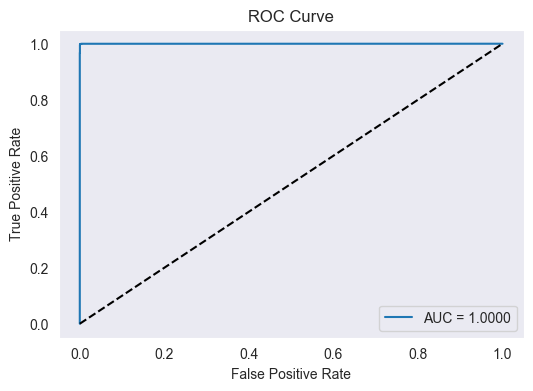

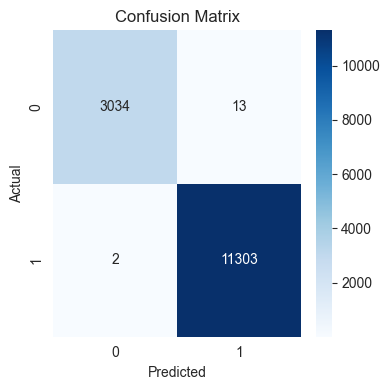

In [ ]:
# 6. Se evalua con métricas completas y gráficos
results = lstm_model.evaluate(X_test, y_test, threshold=0.5)

In [ ]:
# Se guarda el modelo en el path por defecto
lstm_model.save_model()

Modelo guardado en: modelos/lstm_model.keras


In [ ]:
# LSTM: 1 paciente
# 1. Se realiza el preprocesamiento para generar secuencias al dataset (necesario para el algoritmo), en este caso solo para un paciente
df_paciente = df_polars.filter(pl.col("paciente_id") == "PAC_001")
pol_lstm_pac = PolarsPreprocessor(df_paciente)
X_pac, y_pac = pol_lstm_pac.run_all(export_path="data_simulada/preprocesado_Polars.csv", generar_secuencias = True)


In [ ]:
# 2. Se divide el dataset mediante train test split
X_train_pac, X_test_pac, y_train_pac, y_test_pac = train_test_split(X_pac, y_pac, stratify=y_pac, test_size=0.2, random_state=42)

# 3. Se obtiene la forma de entrada para el modelo
input_shape_pac = (X_train_pac.shape[1], X_train_pac.shape[2])

# 4. Se inicializa el modelo
lstm_model_pac = LSTMModel(input_shape=input_shape_pac)

# 5. Se procede con el entrenamiento del modelo
history_pac = lstm_model_pac.train(X_train_pac, y_train_pac, X_val=X_test_pac, y_val=y_test_pac, epochs=20, batch_size=64)

Epoch 1/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.8749 - loss: 0.3338 - val_accuracy: 0.9908 - val_loss: 0.1082
Epoch 2/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9891 - loss: 0.0346 - val_accuracy: 0.9838 - val_loss: 0.0545
Epoch 3/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9942 - loss: 0.0211 - val_accuracy: 0.9955 - val_loss: 0.0125
Epoch 4/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.9952 - loss: 0.0166 - val_accuracy: 0.9969 - val_loss: 0.0109
Epoch 5/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9962 - loss: 0.0117 - val_accuracy: 0.9922 - val_loss: 0.0425
Epoch 6/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.9958 - loss: 0.0126 - val_accuracy: 0.9961 - val_loss: 0.0142
Epoch 7/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9968 - loss: 0.0106 - val_accuracy: 0.9947 - val_loss: 0.0108
Epoch 8/20
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.9947 - loss: 0.0142 - val

113/113 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
 Accuracy: 0.9983
 ROC AUC: 0.9996

 Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      1.00       757
         1.0       1.00      1.00      1.00      2831

    accuracy                           1.00      3588
   macro avg       1.00      1.00      1.00      3588
weighted avg       1.00      1.00      1.00      3588


 Confusion Matrix:
[[ 751    6]
 [   0 2831]]


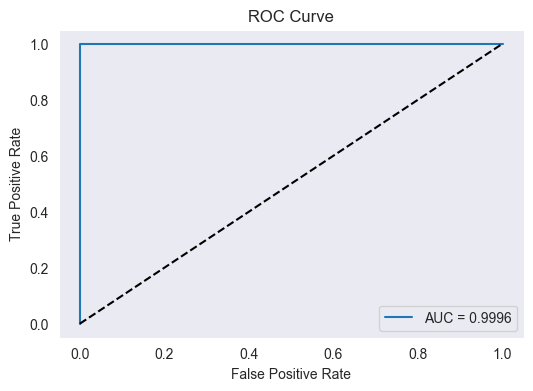

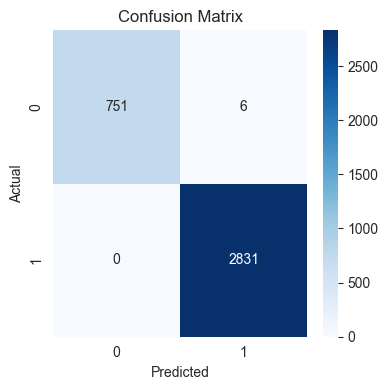

In [ ]:
results_pac = lstm_model_pac.evaluate(X_test_pac, y_test_pac, threshold=0.5)

In [ ]:
lstm_model_pac.save_model(path="modelos/lstm_model_pac.keras")

Modelo guardado en: modelos/lstm_model_pac.keras


In [ ]:
# LSTM: N-1 pacientes (3 pacientes): leave_one_patient_out_validation
def leave_one_patient_out_with_lstm_model(X, y, paciente_ids, input_shape, lstm_params=None,
                                          epochs=10, batch_size=32, verbose=0):
    """
    Validación cruzada Leave-One-Patient-Out usando la clase LSTMModel.

    Args:
        X: np.ndarray (n_samples, seq_len, n_features)
        y: np.ndarray (n_samples,)
        paciente_ids: np.ndarray o list de strings (n_samples,)
        input_shape: tuple (seq_len, n_features)
        lstm_params: dict con hiperparámetros para LSTMModel
        epochs, batch_size: int
        verbose: 0 o 1 para salida de entrenamiento

    Returns:
        resultados: dict con métricas por paciente
    """
    unique_ids = np.unique(paciente_ids)
    all_y_true, all_y_pred, all_y_prob = [], [], []

    resultados = defaultdict(list)

    for pid in tqdm(unique_ids, desc="Validación paciente por paciente"):
        # División de datos
        test_mask = paciente_ids == pid
        train_mask = ~test_mask

        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]

        # Nueva instancia del modelo
        model = LSTMModel(input_shape, **(lstm_params or {}))
        model.train(X_train, y_train, batch_size=batch_size, epochs=epochs, use_early_stopping=True)

        # Predicción
        y_pred, y_prob = model.predict(X_test)

        # Métricas por paciente
        acc = np.mean(y_pred.flatten() == y_test)
        try:
            auc = roc_auc_score(y_test, y_prob)
        except:
            auc = None
            warnings.warn(f"No se pudo calcular AUC para {pid} (una sola clase)")

        resultados["paciente"].append(pid)
        resultados["accuracy"].append(acc)
        resultados["roc_auc"].append(auc)

        print(f"\n Paciente {pid} — Accuracy: {acc:.4f}, ROC AUC: {auc if auc else 'N/A'}")
        print(confusion_matrix(y_test, y_pred))
        print(classification_report(y_test, y_pred, digits=3))

        # Acumulados
        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred.flatten())
        all_y_prob.extend(y_prob.flatten())

    # Métricas globales
    print("\n Resultados Globales:")
    print(confusion_matrix(all_y_true, all_y_pred))
    print(classification_report(all_y_true, all_y_pred, digits=3))

    try:
        global_auc = roc_auc_score(all_y_true, all_y_prob)
        print(f"ROC AUC global: {global_auc:.4f}")
    except:
        print("ROC AUC global no se pudo calcular")

    return resultados



In [ ]:
# 2. Obtener paciente_ids alineados
input_shape = (X.shape[1], X.shape[2])
seq_length = 60
step = 1

exclude_cols = ['timestamp', 'paciente_id', 'empeoramiento']
exclude_keywords = ['etiqueta', 'sostenida']

features = [
    col for col in df_polars.columns
    if col not in exclude_cols and
       not any(kw in col.lower() for kw in exclude_keywords)
]

paciente_ids = []

for paciente_id in df_polars['paciente_id'].unique().to_list():
    grupo = df_polars.filter(pl.col("paciente_id") == paciente_id).select(features + ['empeoramiento'])
    grupo_np = grupo.to_numpy()

    for i in range(0, len(grupo_np) - seq_length, step):
        paciente_ids.append(paciente_id)

paciente_ids = np.array(paciente_ids)

# 3. Validación cruzada LOPO
resultados_lopo = leave_one_patient_out_with_lstm_model(
    X, y, paciente_ids,
    input_shape=input_shape,
    lstm_params={
        'lstm_units_1': 64,
        'lstm_units_2': 32,
        'dense_units': 64,
        'dropout_rate': 0.2,
        'learning_rate': 0.001
    },
    epochs=10,
    batch_size=32,
    verbose=0
)


Validación paciente por paciente:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 65s 36ms/step - accuracy: 0.9504 - loss: 0.1415
Epoch 2/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 75s 44ms/step - accuracy: 0.9935 - loss: 0.0196
Epoch 3/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 67s 40ms/step - accuracy: 0.9950 - loss: 0.0151
Epoch 4/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 56s 33ms/step - accuracy: 0.9963 - loss: 0.0121
Epoch 5/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 52s 31ms/step - accuracy: 0.9966 - loss: 0.0108
Epoch 6/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9973 - loss: 0.0092
Epoch 7/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - accuracy: 0.9982 - loss: 0.0062
Epoch 8/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 62s 37ms/step - accuracy: 0.9985 - loss: 0.0049
Epoch 9/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 63s 38ms/step - accuracy: 0.9985 - loss: 0.0048
Epoch 10/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9987 - loss: 0.0042
561/561 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step


Validación paciente por paciente:  25%|██▌       | 1/4 [10:21<31:04, 621.35s/it]


 Paciente PAC_001 — Accuracy: 0.9942, ROC AUC: 0.9995490141236377
[[ 3736    50]
 [   54 14100]]
              precision    recall  f1-score   support

         0.0      0.986     0.987     0.986      3786
         1.0      0.996     0.996     0.996     14154

    accuracy                          0.994     17940
   macro avg      0.991     0.991     0.991     17940
weighted avg      0.994     0.994     0.994     17940

Epoch 1/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 70s 36ms/step - accuracy: 0.9488 - loss: 0.1427
Epoch 2/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.9929 - loss: 0.0224
Epoch 3/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9945 - loss: 0.0158
Epoch 4/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9961 - loss: 0.0131
Epoch 5/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.9966 - loss: 0.0108
Epoch 6/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 58s 35ms/step - accuracy: 0.9971 - loss: 0.0086
Epoch 7/10
1682/1682 ━━━━━━━━━━━━━━

Validación paciente por paciente:  50%|█████     | 2/4 [20:36<20:35, 617.94s/it]

...

Validación paciente por paciente:  75%|███████▌  | 3/4 [30:37<10:10, 610.10s/it]


 Paciente PAC_003 — Accuracy: 0.9955, ROC AUC: 0.9998569834565255
[[ 3743    60]
 [   20 14117]]
              precision    recall  f1-score   support

         0.0      0.995     0.984     0.989      3803
         1.0      0.996     0.999     0.997     14137

    accuracy                          0.996     17940
   macro avg      0.995     0.991     0.993     17940
weighted avg      0.996     0.996     0.996     17940

Epoch 1/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 69s 35ms/step - accuracy: 0.9509 - loss: 0.1440
Epoch 2/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.9938 - loss: 0.0196
Epoch 3/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.9951 - loss: 0.0142
Epoch 4/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9959 - loss: 0.0123
Epoch 5/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9966 - loss: 0.0091
Epoch 6/10
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 60s 36ms/step - accuracy: 0.9973 - loss: 0.0080
Epoch 7/10
1682/1682 ━━━━━━━━━━━━━━

Validación paciente por paciente: 100%|██████████| 4/4 [41:05<00:00, 616.44s/it]


 Paciente PAC_004 — Accuracy: 0.9940, ROC AUC: 0.9976109933578005
[[ 3752    50]
 [   58 14080]]
              precision    recall  f1-score   support

         0.0      0.985     0.987     0.986      3802
         1.0      0.996     0.996     0.996     14138

    accuracy                          0.994     17940
   macro avg      0.991     0.991     0.991     17940
weighted avg      0.994     0.994     0.994     17940


 Resultados Globales:
[[15019   216]
 [  186 56339]]


              precision    recall  f1-score   support

         0.0      0.988     0.986     0.987     15235
         1.0      0.996     0.997     0.996     56525

    accuracy                          0.994     71760
   macro avg      0.992     0.991     0.992     71760
weighted avg      0.994     0.994     0.994     71760

ROC AUC global: 0.9992
